IMPORTING THE DATASET

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import seaborn as sns
import plotly.express as px

ytt=pd.read_csv("ytt.csv")
ytt["publish_date"]=pd.to_datetime(ytt["publish_date"])

ytt.info()

ModuleNotFoundError: No module named 'pandas'

HANDLING MISSING VALUES

In [25]:
print(ytt.isnull().sum())

video_id                 0
trending_date            0
title                    0
channel_title            0
category_id              0
publish_date             0
time_frame               0
published_day_of_week    0
publish_country          0
views                    0
likes                    0
dislikes                 0
comment_count            0
like_ratio               0
comment_ratio            0
dislike_ratio            0
dtype: int64


SEPARATING NUMERIC AND NON-NUMERIC COLUMNS

In [39]:
numeric=ytt.select_dtypes(include=["number"]).columns
numeric

Index(['category_id', 'views', 'likes', 'dislikes', 'comment_count',
       'like_ratio', 'comment_ratio', 'dislike_ratio'],
      dtype='object')

In [52]:
non_numeric=ytt.select_dtypes(exclude=["number"]).columns
non_numeric

Index(['video_id', 'trending_date', 'title', 'channel_title', 'publish_date',
       'time_frame', 'published_day_of_week', 'publish_country'],
      dtype='object')

FILLING THE MISSING VALUES

Filling using Mean

In [64]:
imputern=SimpleImputer(strategy="mean")
ytt[numeric]=imputern.fit_transform(ytt[numeric])
ytt.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   video_id               999 non-null    object        
 1   trending_date          999 non-null    object        
 2   title                  999 non-null    object        
 3   channel_title          999 non-null    object        
 4   category_id            999 non-null    float64       
 5   publish_date           999 non-null    datetime64[ns]
 6   time_frame             999 non-null    object        
 7   published_day_of_week  999 non-null    object        
 8   publish_country        999 non-null    object        
 9   views                  999 non-null    float64       
 10  likes                  999 non-null    float64       
 11  dislikes               999 non-null    float64       
 12  comment_count          999 non-null    float64       
 13  like_

Filling using Mode

In [75]:
imputernn=SimpleImputer(strategy="most_frequent")
ytt[non_numeric]=imputernn.fit_transform(ytt[non_numeric])
ytt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   video_id               999 non-null    object        
 1   trending_date          999 non-null    object        
 2   title                  999 non-null    object        
 3   channel_title          999 non-null    object        
 4   category_id            999 non-null    float64       
 5   publish_date           999 non-null    datetime64[ns]
 6   time_frame             999 non-null    object        
 7   published_day_of_week  999 non-null    object        
 8   publish_country        999 non-null    object        
 9   views                  999 non-null    float64       
 10  likes                  999 non-null    float64       
 11  dislikes               999 non-null    float64       
 12  comment_count          999 non-null    float64       
 13  like_

SUMMARY STATISTICS

In [85]:
ytt.describe()

,category_id,publish_date,views,likes,dislikes,comment_count,like_ratio,comment_ratio,dislike_ratio
count,999.000000,999,9.990000e+02,9.990000e+02,999.000000,999.000000,999.000000,999.000000,999.000000
mean,19.703109,2017-10-10 22:36:23.783783680,1.017535e+06,3.873273e+04,1589.216433,3847.330661,0.036256,0.004824,0.001776
min,1.000000,2010-01-14 00:00:00,6.870000e+02,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,2017-10-11 00:00:00,7.648300e+04,1.879500e+03,70.000000,259.500000,0.013098,0.001743,0.000531
50%,23.000000,2017-11-13 00:00:00,2.461340e+05,7.018000e+03,224.000000,872.000000,0.031317,0.003307,0.001014
75%,25.000000,2017-11-15 00:00:00,8.146060e+05,2.332450e+04,992.000000,2901.500000,0.049829,0.005919,0.001791
max,28.000000,2017-12-11 00:00:00,4.344965e+07,1.788960e+06,53873.000000,127481.000000,0.761451,0.057723,0.049189
std,7.597735,NaN,3.042141e+06,1.324885e+05,4999.277693,11888.308474,0.037721,0.005456,0.003638


ENGAGEMENT METRICS

In [124]:
Total_likes=ytt["likes"].sum()
Total_views=ytt["views"].sum()
Total_dislikes=ytt["dislikes"].sum()
Total_comments=ytt["comment_count"].sum()
print("Total Views:",Total_views)
print("Total Likes:",Total_likes)
print("Total Dislikes:",Total_dislikes)
print("Total Comments:",Total_comments)

Total Views: 1016517677.2124249
Total Likes: 38693999.46439318
Total Dislikes: 1587627.2164328657
Total Comments: 3843483.330661323


VISUALIZING USING PLOTS

Ratios using Scatter Plot

    category_id  like_ratio  comment_count
0      1.000000    0.048582    2463.551020
1      2.000000    0.020257     945.625000
2     10.000000    0.055350   10146.913793
3     15.000000    0.049429     827.590909
4     17.000000    0.012810     552.987179
5     19.000000    0.005639     273.111111
6     19.703109    0.042409    2029.000000
7     20.000000    0.059575    2169.857143
8     22.000000    0.033436    3182.841270
9     23.000000    0.045194    5169.597561
10    24.000000    0.031318    2780.194552
11    25.000000    0.009326     736.939394
12    26.000000    0.045106    2561.025974
13    27.000000    0.038178    1894.229167
14    28.000000    0.030337    3425.479452


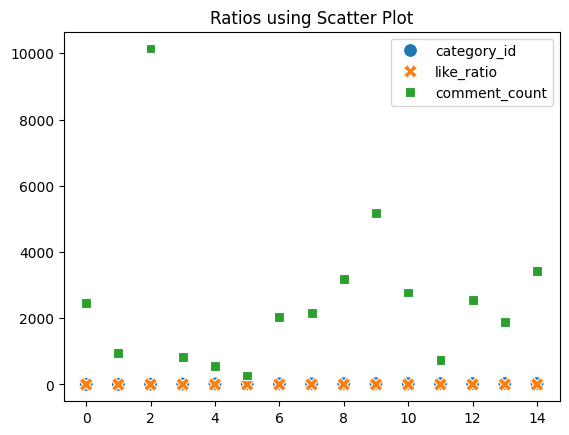

In [ ]:
ytt['like_ratio'] = ytt['likes'] / ytt['views']
ytt['comment_ratio'] = ytt['comment_count'] / ytt['views']
ratios=ytt[["category_id","like_ratio","comment_count"]].groupby("category_id").mean().reset_index()
print(ratios)
sns.scatterplot(ratios,s=100,)
plt.title("Ratios using Scatter Plot")
plt.show()
ytt['dislike_ratio'] = ytt['dislikes'] / ytt['views']



In [177]:
engament_rate=(Total_likes+Total_dislikes+Total_comments)/Total_views*100
print("Engagement Rate:",engament_rate)

Engagement Rate: 4.340810888059591


In [178]:
like_ratio=Total_likes/(Total_likes/Total_dislikes)*100
print("Like Ratio:",like_ratio)

Like Ratio: 158762721.6432866


In [179]:
c_titles_like=ytt.groupby("channel_title")["likes"].sum()
print("Channel wise Likes:",c_titles_like)

Channel wise Likes: channel_title
12 News                352.000000
20th Century Fox    684803.732197
2CELLOS              22900.000000
60 Minutes             514.000000
90s Commercials          2.000000
                        ...      
reputationswift       1137.000000
standupmaths         16443.000000
theneedledrop        39904.000000
todrickhall          40065.000000
vlogbrothers          5896.000000
Name: likes, Length: 342, dtype: float64


OVERVIEW CHARTS

Top Categories using Pie Chart

category_id
24.0    233
10.0    174
23.0     82
17.0     78
26.0     77
28.0     73
25.0     66
22.0     63
1.0      49
27.0     48
Name: count, dtype: int64


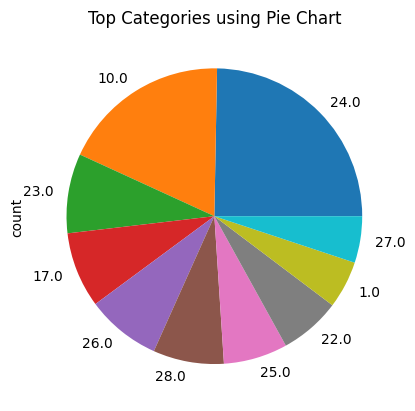

In [183]:
top_cats=ytt["category_id"].value_counts().nlargest(10)
print(top_cats)
top_cats.plot(kind="pie")
plt.title("Top Categories using Pie Chart")
plt.show()

Distribution of Video Views using Histogram

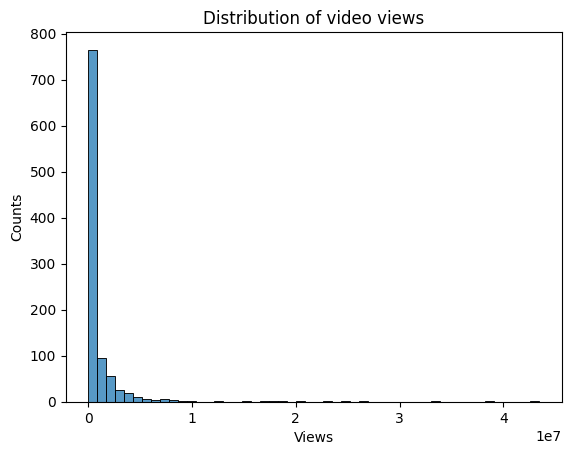

In [184]:
sns.histplot(ytt["views"],bins=50)
plt.title("Distribution of video views")
plt.xlabel("Views")
plt.ylabel("Counts")
plt.show()

In [2]:
top_cats = ytt['category_id'].value_counts().nlargest(10).reset_index()
top_cats.columns = ['category_id', 'video_count']

fig = px.bar(top_cats, x='category_id', y='video_count',
             title="Top 10 Trending Categories", text='video_count')
fig.show()

NameError: name 'ytt' is not defined

TIME SERIES ANALYSIS

Average Views by Days using Line Plot

published_day_of_week
Friday       2.095868e+06
Monday       5.166087e+05
Saturday     5.279305e+05
Sunday       8.837314e+05
Thursday     1.597661e+06
Tuesday      6.182907e+05
Wednesday    6.318776e+05
Name: views, dtype: float64


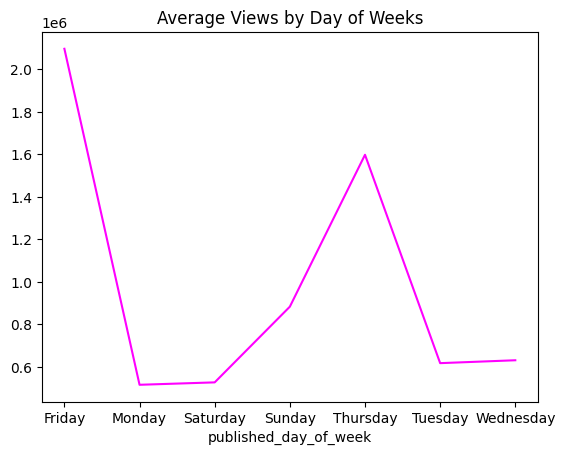

In [ ]:
day_avg=ytt.groupby("published_day_of_week")["views"].mean()
print(day_avg)
day_avg.plot(kind="line",color="magenta",title="Average Views by Day of Weeks")
plt.show()

Distribution of Days to trend using Box Plot

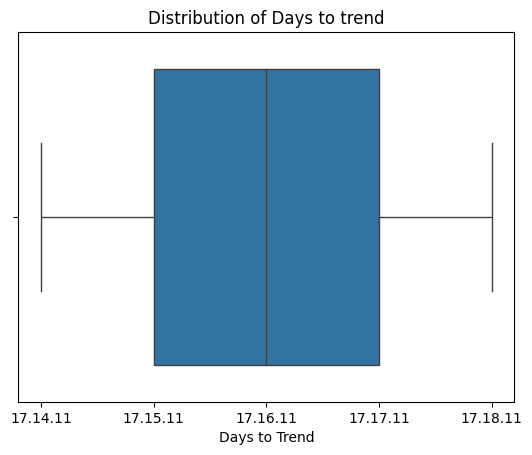

In [ ]:
sns.boxplot(x=ytt["trending_date"])
plt.title("Distribution of Days to trend")
plt.xlabel("Days to Trend")
plt.show()

COUNTRY_WISE ANALYSIS

Average Views by Country using Area Plot

  publish_country         views
0              AU  9.389840e+05
1              BR  7.497715e+05
2              CA  1.085630e+06
3              GB  8.913759e+05
4              IN  8.065227e+05
5              JP  1.196026e+06
6              US  1.431092e+06


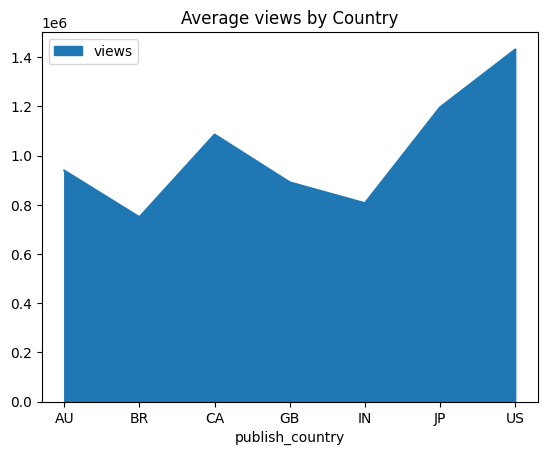

In [ ]:
country_views=ytt.groupby("publish_country")["views"].mean().reset_index()
print(country_views)
country_views.plot(kind="area",x="publish_country",y="views",title="Average views by Country")
plt.show()

Country Counts using Bar Plot

  publish_country  count
0              JP    162
1              BR    146
2              GB    141
3              US    141
4              AU    138
5              IN    136
6              CA    135


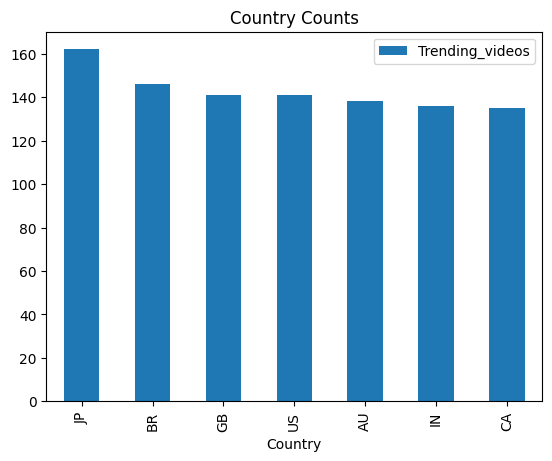

In [186]:
Country_counts=ytt["publish_country"].value_counts().reset_index()
print(Country_counts)
Country_counts.columns=["Country","Trending_videos"]
Country_counts.plot(kind="bar",x="Country",y="Trending_videos",title="Country Counts")
plt.show()
#Country_counts.columns=["Country","Trending_videos"]
#Country_counts.plot(kind="pie",names="Country",values="Trending_videos")
#plt.show()
##fig=px.pie(Country_counts,names="Country",values="Trending_videos")
#fig.show()

CORRELATION INSIGHTS

Correlation between Engagement Metrics using Heatmap

                  views     likes  dislikes  comment_count
views          1.000000  0.912659  0.740181       0.810888
likes          0.912659  1.000000  0.637813       0.860917
dislikes       0.740181  0.637813  1.000000       0.765953
comment_count  0.810888  0.860917  0.765953       1.000000


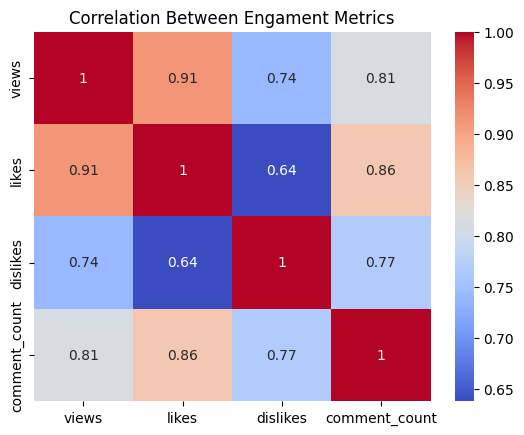

In [187]:
corr=ytt[["views","likes","dislikes","comment_count"]].corr()
print(corr)
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Between Engament Metrics")
plt.show()